# Supplementary Figure S39: interaction evidence

Read the paired No-LR and stVCR error tables, recalculate the displayed comparisons, and draw all four panels.

## How this figure is made

Follow the steps from top to bottom. Each command names its input, the files it
creates, and the calculation that uses those files next.

Replace text inside angle brackets with your path or value. For example,
`<output-dir>` means the directory where you want the files to be written.

### 1. fit and evaluate Full and No-LR models

Used for: S39a-b

```text
matched ablation workflow in scripts/run_matched_ablation_matrix.py and scripts/run_matched_ablation_benchmark_evaluation.py
```

Input: `five manuscript aligned H5ADs; matched Full/No-LR configs; seed 42`

Creates: `per-arm full_data_metrics_long.csv and evaluation manifests`

Continue with: `paired post-compute merge`

### 2. prepare held-out benchmark inputs

Used for: S39c-d

```text
python -m scripts.spatiotemporal_benchmark.run_unified_benchmark --datasets zebrafish mosta arista admouse chicken_heart --model-runs <matched-model-runs> --run-root <benchmark-run> prepare
```

Input: `shared target omissions and deterministic 5,000-particle source rosters`

Creates: `held-out inputs and source rosters for every target stage`

Continue with: `run CytoBridge and stVCR`

### 3. run held-out CytoBridge and stVCR

Used for: S39c-d

```text
python -m scripts.spatiotemporal_benchmark.run_unified_benchmark --datasets zebrafish mosta arista admouse chicken_heart --model-runs <matched-model-runs> --run-root <benchmark-run> --software-root <method-checkouts> run --methods cytobridge stvcr --tracks loto --device cuda
```

Input: `held-out inputs, source rosters, and the two installed methods`

Creates: `one prediction folder for each method, dataset, and target stage`

Continue with: `evaluate the predictions`

### 4. evaluate held-out predictions

Used for: S39c-d

```text
python -m scripts.spatiotemporal_benchmark.run_unified_benchmark --datasets zebrafish mosta arista admouse chicken_heart --model-runs <matched-model-runs> --run-root <benchmark-run> evaluate --tracks loto
```

Input: `held-out truth and CytoBridge/stVCR predictions`

Creates: `target-stage means and method support records`

Continue with: `pair the results for S39`

### 5. validate and merge

Used for: S39

```text
build_s35_postcompute_bundle.py
```

Input: `matched Full/No-LR metrics; CytoBridge/stVCR LOTO metrics; native-support records`

Creates: `no_lr_paired_target_deltas.csv; stvcr_paired_target_deltas.csv; panel_summary.csv`

Continue with: `draw S39`

This step joins matched target stages before plotting the comparison.

### 6. draw from paired target rows

Used for: S39

```text
python scripts/execute_paper_notebooks.py --notebook lr_prior_ablation_stvcr --output-dir <notebook-run>
```

Input: `no_lr_paired_target_deltas.csv; stvcr_paired_target_deltas.csv`

Creates: `interaction_evidence_no_lr_stvcr.pdf/.png and panel summaries`

Continue with: `finished figure`

## Imports and configuration

In [1]:
import pandas as pd

pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)

from pathlib import Path

from IPython.display import Image, display

from CytoBridge.results import (
    load_interaction_evidence_results,
    plot_interaction_evidence,
)
from CytoBridge.results.interaction_evidence import (
    interaction_evidence_statistics,
    write_interaction_evidence_tables,
)

output_dir = Path("outputs") / "interaction_evidence"
output_dir.mkdir(parents=True, exist_ok=True)

## Load processed results

In [2]:
results = load_interaction_evidence_results()
display(results.no_lr.head())
display(results.stvcr.head())

,dataset,target,space,metric,full,no_lr_prior,no_lr_prior_minus_full,no_lr_prior_relative_to_full
0,zebrafish,1,joint,sliced_w2,0.027367,0.048532,0.021165,0.773384
1,zebrafish,1,spatial,sliced_w2,0.016100,0.019290,0.003190,0.198120
2,zebrafish,1,state,sliced_w2,0.027621,0.053158,0.025537,0.924544
3,zebrafish,2,joint,sliced_w2,0.038902,0.058765,0.019863,0.510584
4,zebrafish,2,spatial,sliced_w2,0.019253,0.026927,0.007674,0.398610


,dataset,target,space,CytoBridge-0.015,stVCR,stvcr_minus_cytobridge,stvcr_relative_to_cytobridge
0,zebrafish,1,joint,0.058313,0.110448,0.052135,0.894050
1,zebrafish,1,spatial,0.049454,0.189775,0.140321,2.837419
2,zebrafish,1,state,0.056534,0.106451,0.049917,0.882957
3,zebrafish,2,joint,0.056431,0.124771,0.068340,1.211034
4,zebrafish,2,spatial,0.044071,0.299843,0.255772,5.803604


## Recalculate panel data

Full and No-LR are independently trained matched models from one seed. The CytoBridge–stVCR comparison uses separate LOTO fits and stVCR's native output support. Each target–space value averages five projection sets before pairing; s.e.m. is calculated across target stages.

In [3]:
display(results.panel_summary)

,comparison,dataset,space,n_targets,mean_relative_difference,sem,dataset_mean_relative_difference
0,No LR prior minus full model,zebrafish,joint,4,0.079843,0.369134,0.135283
1,No LR prior minus full model,zebrafish,spatial,4,0.189165,0.157592,0.135283
2,No LR prior minus full model,zebrafish,state,4,0.136841,0.409225,0.135283
3,No LR prior minus full model,mosta,joint,3,0.317666,0.276717,0.261302
4,No LR prior minus full model,mosta,spatial,3,0.019503,0.131026,0.261302
5,No LR prior minus full model,mosta,state,3,0.446737,0.398854,0.261302
6,No LR prior minus full model,arista,joint,4,1.958326,0.317498,1.772661
7,No LR prior minus full model,arista,spatial,4,0.143338,0.047017,1.772661
8,No LR prior minus full model,arista,state,4,3.216319,0.775124,1.772661
9,No LR prior minus full model,admouse,joint,2,0.238860,0.092172,0.254568


## Render and save the figure

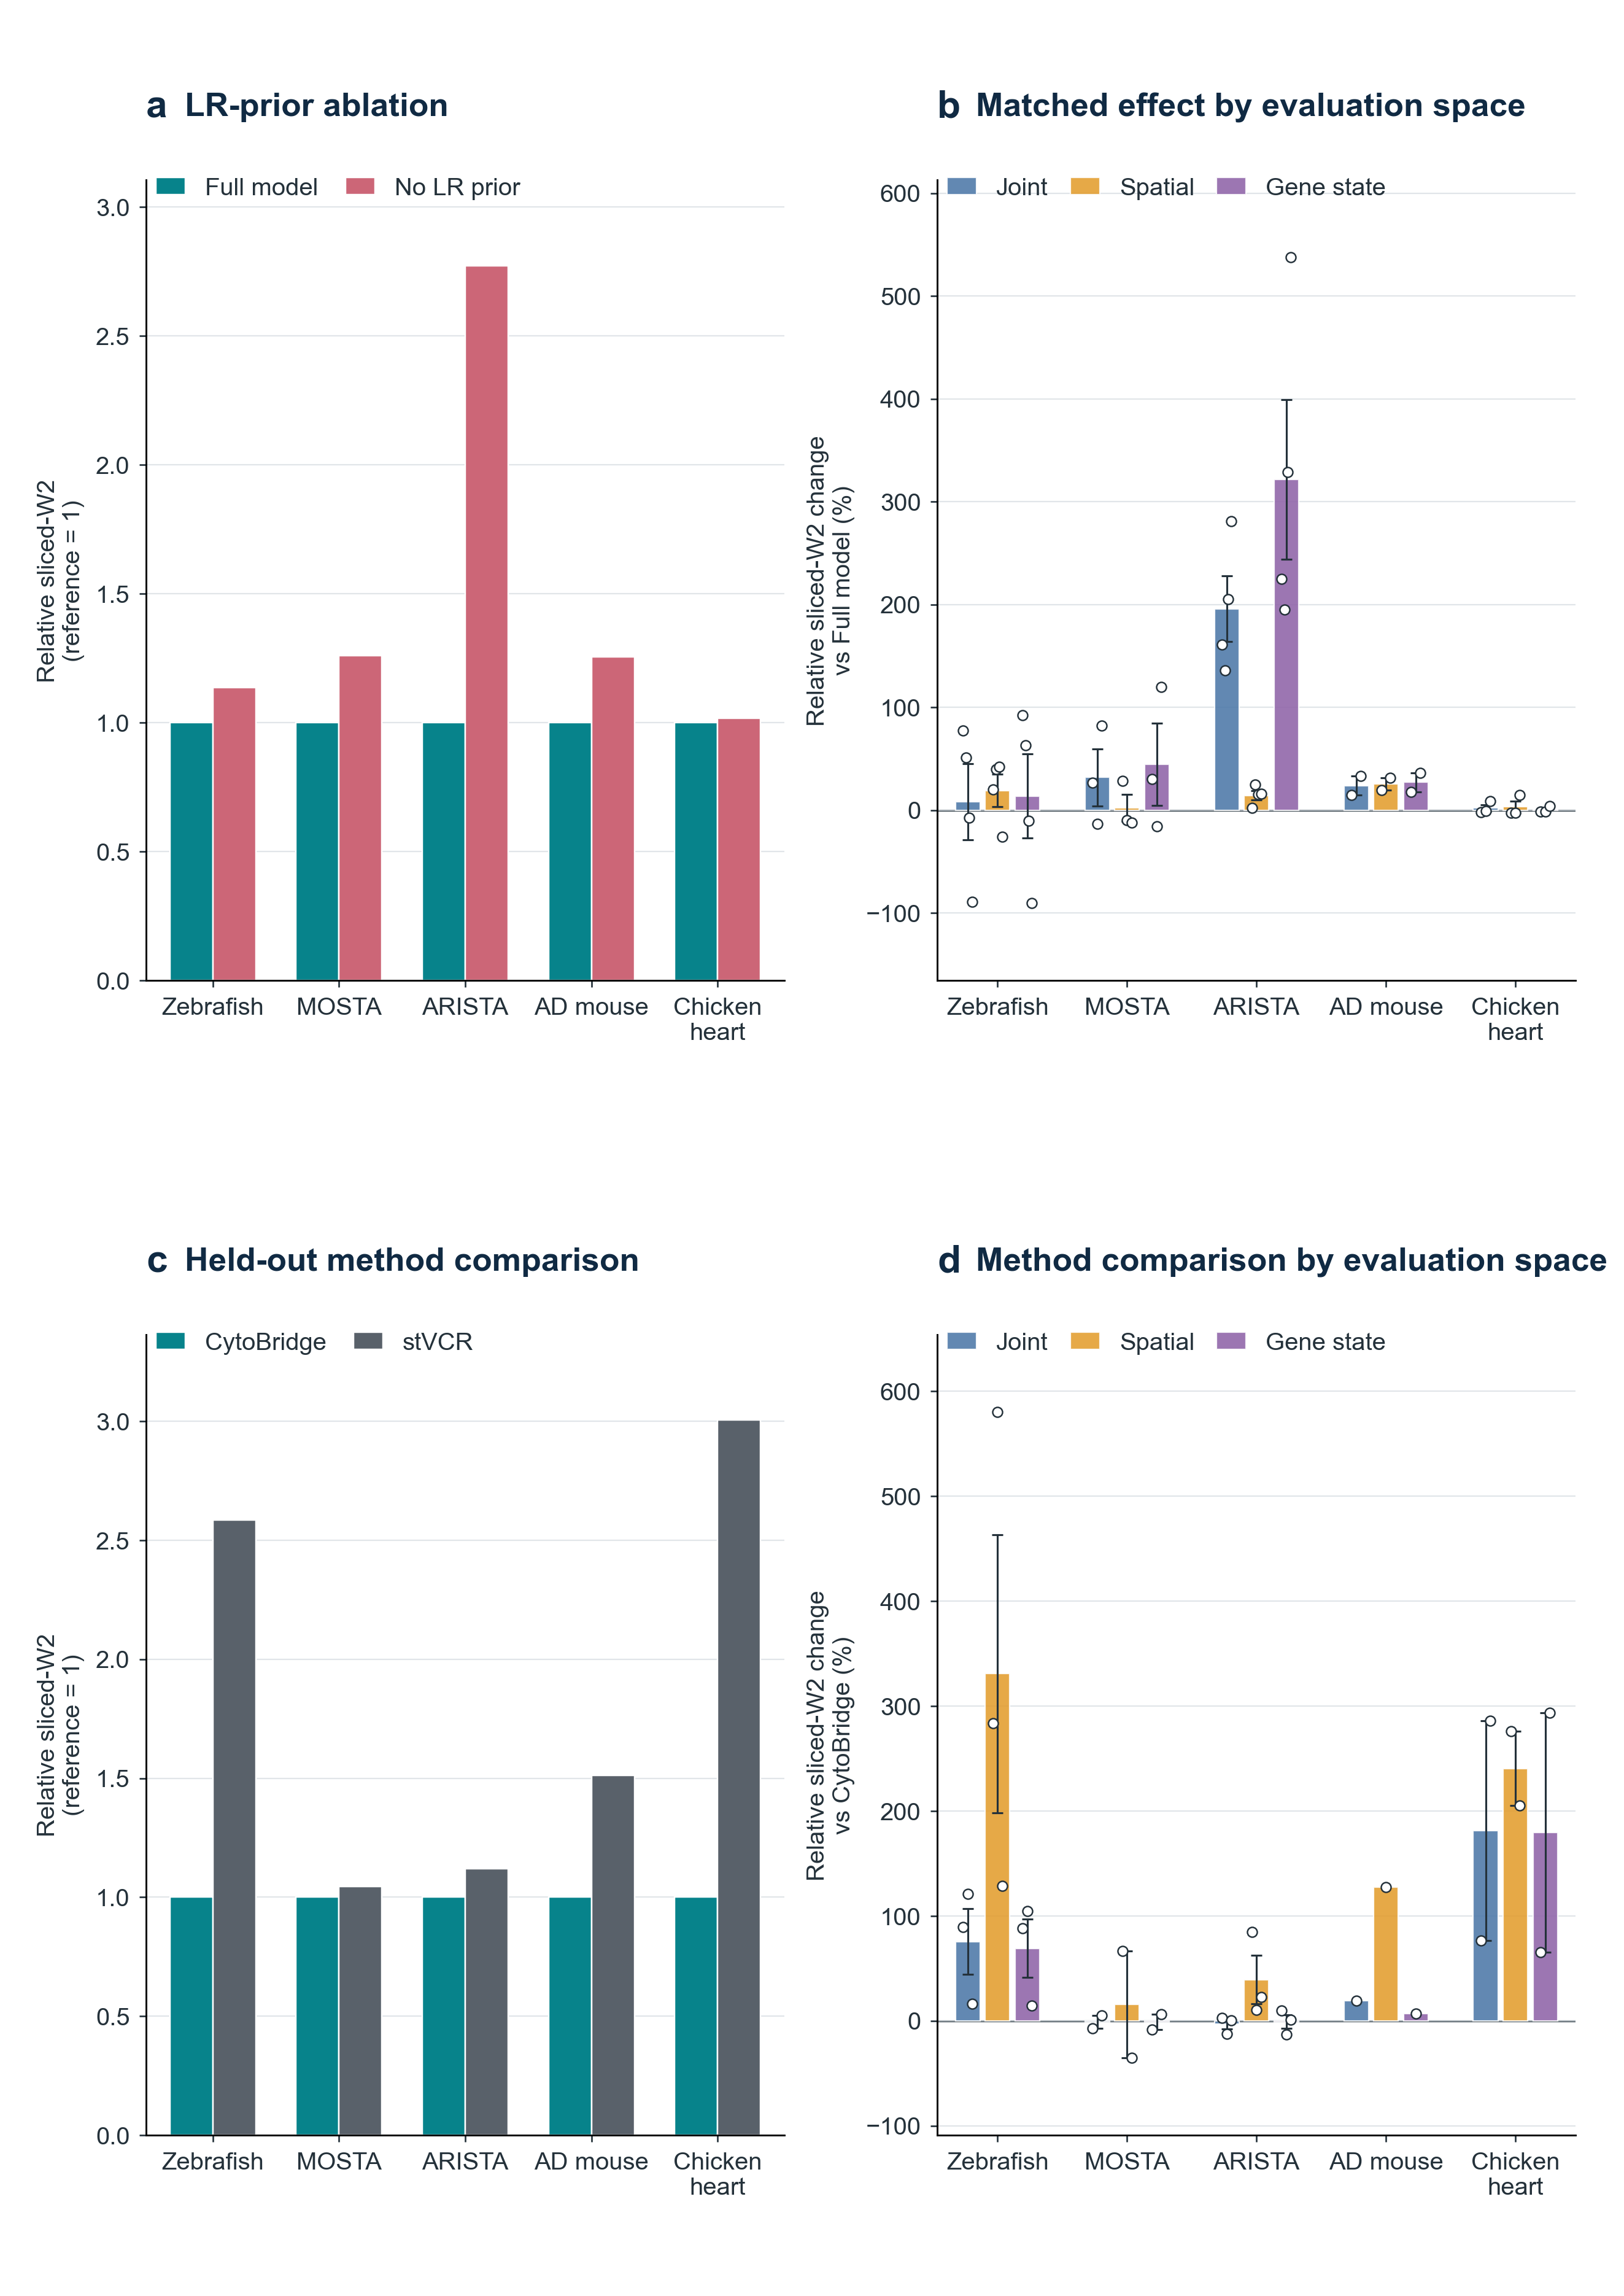

In [4]:
table_paths = write_interaction_evidence_tables(results, output_dir)
pdf_path, png_path = plot_interaction_evidence(results, output_dir)
display(Image(filename=str(png_path), width=700))

## Check outputs

In [5]:
{
    "statistics": interaction_evidence_statistics(results),
    "tables": {name: path.is_file() for name, path in table_paths.items()},
    "pdf": pdf_path.is_file(),
    "png": png_path.is_file(),
}

{'statistics': {'matched_cells': 48,
  'external_comparison_cells': 33,
  'panel_summary_rows': 30,
  'no_lr_mean_relative_change_arista': 1.772661196476827,
  'no_lr_mean_relative_change_chicken_heart': 0.01817799522095409},
 'tables': {'no_lr': True, 'external_comparison': True, 'panel_summary': True},
 'pdf': True,
 'png': True}

## Upstream analysis and API

The command-line entry is `scripts/results/plot_interaction_evidence.py`. The reader API is in `CytoBridge/results/interaction_evidence.py`. Model fitting and projection generation are upstream of the packaged tables.